<a href="https://colab.research.google.com/github/krishnakanthkona-3110/Interview_Prep/blob/main/Interview_Notes_Nueral_Networks_Deep_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

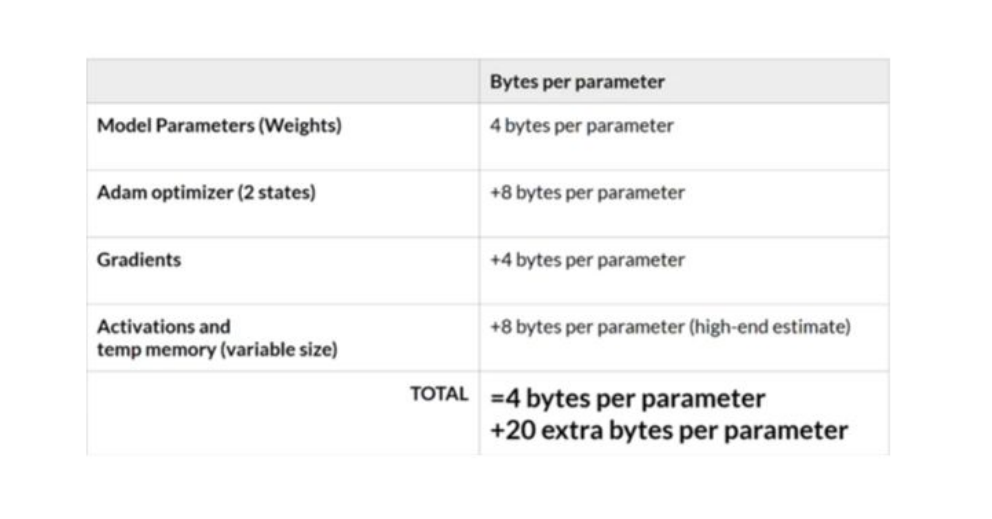

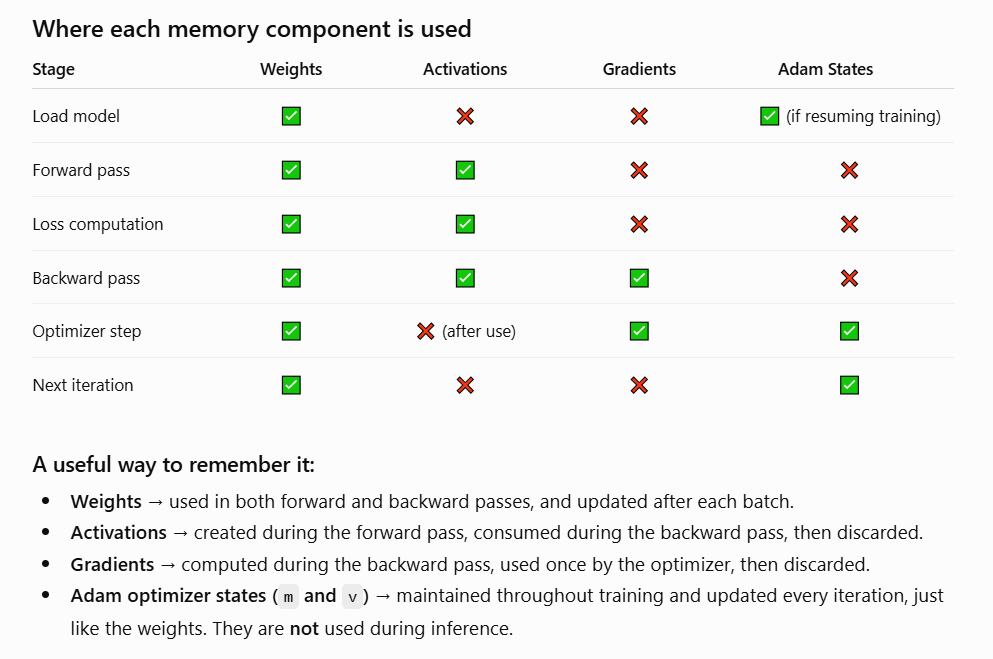

# During training a model



*   Step 1: Load Model Parameters (Weights)

Memory used:

✅ Model parameters (4 bytes/parameter)

At this point, only the weights need to be in GPU memory.


*   Step 2: Forward Pass

The input passes through the network.

Each layer computes:

Activation = f(W × Input + b)

Memory now contains:

✅ Weights

✅ Activations

These activations are stored because they are needed later for backpropagation.

*   Step 3: Compute Loss

The prediction is compared with the true label.

The loss is a single number.

No gradients yet.

Memory: Weights, Activations, Loss

*   Step 4: Backward Pass (Backpropagation)

Now we compute gradients.

The chain rule is applied from the output layer back to the input layer.

For every weight:

Gradient = ∂Loss / ∂Weight

These gradients are stored in memory.

Memory now contains:

✅ Weights
✅ Activations
✅ Gradients

*   Step 5: Optimizer Uses Its States (Adam)

Now Adam updates every weight.

Adam already stores:

m = moving average of gradients

v = moving average of squared gradients

New_Weight = Weight - learning_rate × corrected_gradient

These optimizer states persist across training iterations.

Memory contains:

Weights,
Adam state (m),
Adam state (v),
Gradients (temporarily)


*   Step 6: Update Weights

The optimizer updates the model.

Old Weight

↓

Optimizer

↓

New Weight

The weights now contain the learned information from this batch.



*   Step 7: Clear Temporary Memory

After the optimizer step:

Activations are no longer needed.
Gradients are no longer needed.

They are freed from memory (or overwritten in the next iteration).

Only these remain:

✅ Updated weights
✅ Adam optimizer states

Then the next batch starts.








Training = Weights + Activations + Gradients + Optimizer States


Inference = Weights + Activations (+ KV Cache for LLMs)

TRAINING

Weights
   │
Forward Pass
   │
Activations
   │
Loss
   │
Backward Pass
   │
Gradients
   │
Optimizer
   │
Updated Weights

INFERENCE

Weights
   │
Forward Pass
   │
Activations
   │
Prediction

Inference requires only the model weights, temporary activations, and (for Transformer-based LLMs) the KV cache. It does not require gradients or optimizer states because there is no backpropagation or weight update.

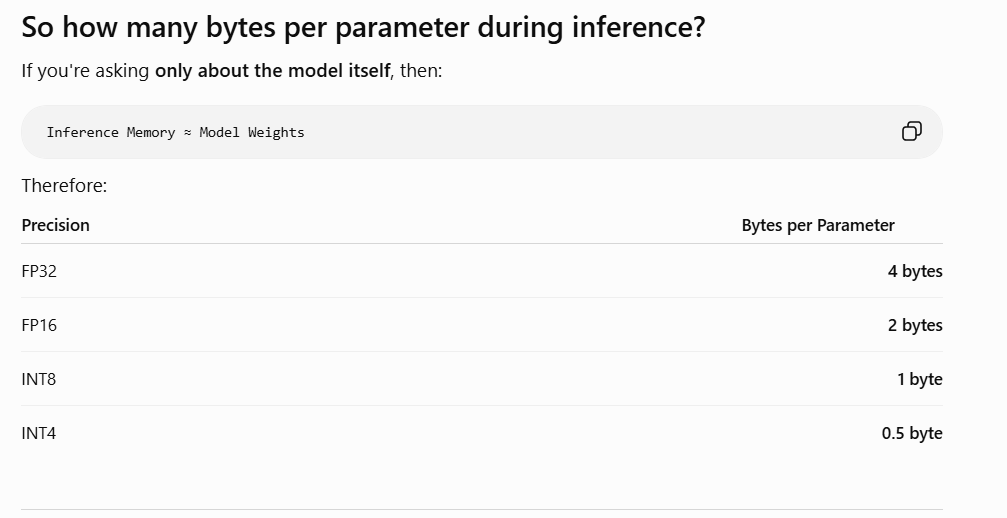

# Why are activations estimated as 8 bytes per parameter?

- The activation function itself doesn't consume 8 bytes. The memory is used to store the activations (layer outputs) generated during the forward pass. These activations must be retained until the backward pass to compute gradients. The commonly cited "8 bytes per parameter" is only a rough approximation for training memory in FP32; actual activation memory depends on the model architecture, batch size, sequence length, hidden size, and number of layers—not directly on the number of parameters.

# Activation Function:-

An activation function is a mathematical function that transforms a neuron's output before passing it to the next layer. Its primary purpose is to introduce non-linearity into the neural network.

Without activation functions, a neural network would behave like a single linear transformation regardless of how many layers it has, making it unable to learn complex patterns such as language, images, or speech.


- An activation function is a mathematical function that introduces non-linearity into a neural network, allowing it to learn complex patterns that cannot be captured by linear models alone.

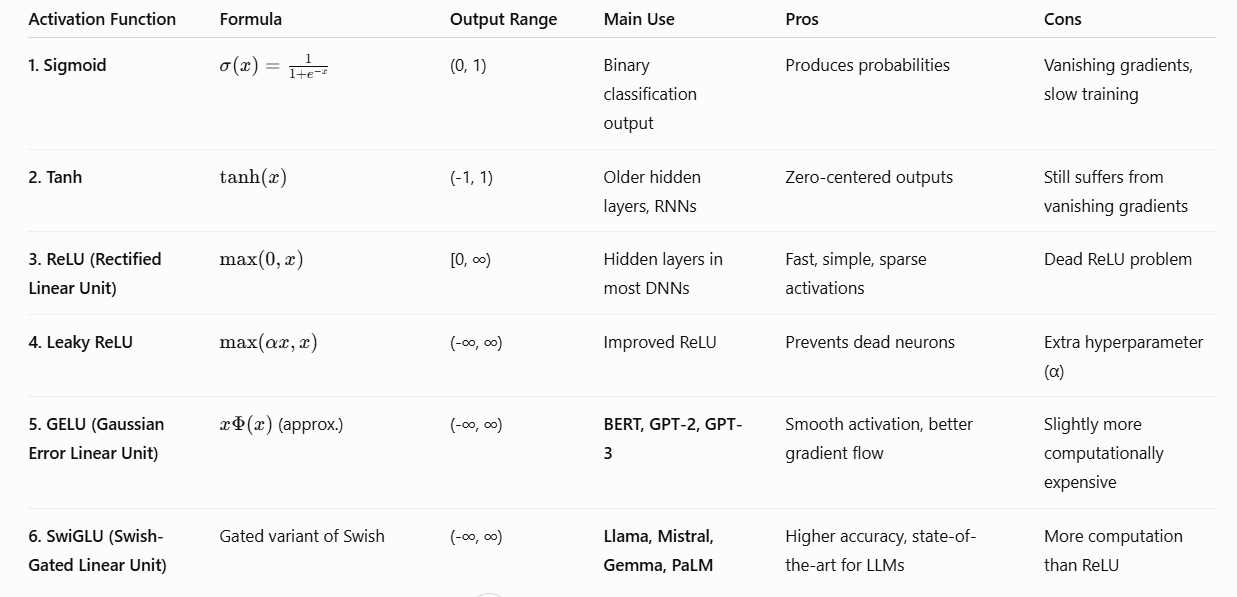

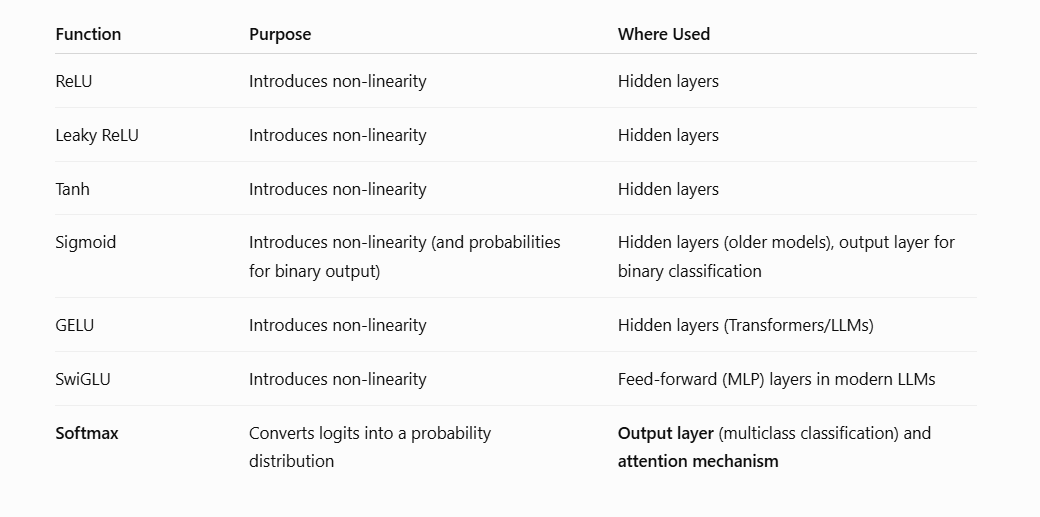

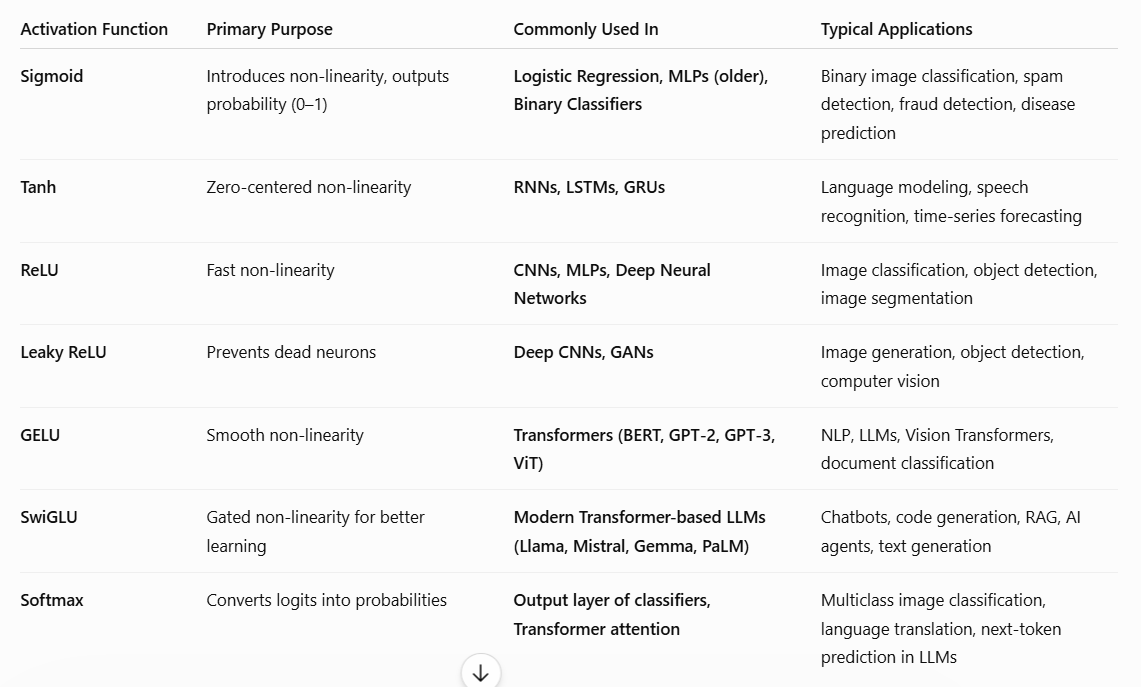

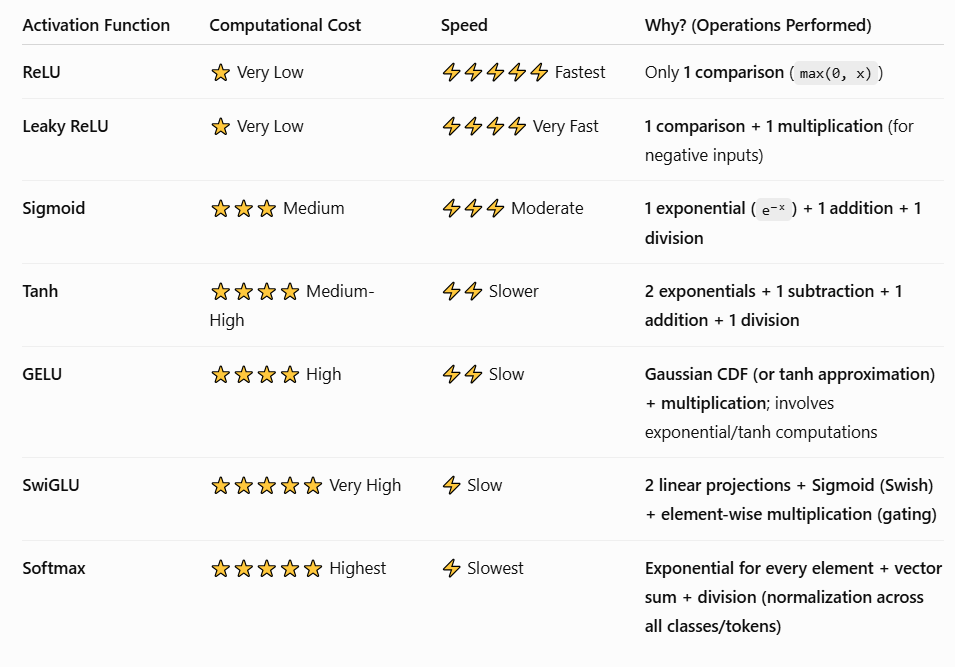